##Problem 1 - RNN

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
import string
import glob

In [2]:
!wget https://download.pytorch.org/tutorial/data.zip
!unzip data.zip

--2026-04-22 02:05:43--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 13.35.186.68, 13.35.186.109, 13.35.186.92, ...
Connecting to download.pytorch.org (download.pytorch.org)|13.35.186.68|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]   2.75M  --.-KB/s    in 0.09s   

2026-04-22 02:05:43 (32.2 MB/s) - ‘data.zip’ saved [2882130/2882130]

Archive:  data.zip
   creating: data/
  inflating: data/eng-fra.txt        
   creating: data/names/
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: data/names/Itali

In [3]:
all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

def letterToIndex(letter):
  return all_letters.find(letter)

def lineToTensor(line):
  tensor = torch.zeros(len(line), 1, n_letters)
  for li, letter in enumerate(line):
    index = letterToIndex(letter)
    tensor[li][0][index] = 1
  return tensor

In [5]:
data_path = "data/names/*.txt"
category_lines = {}
all_categories = []

for filename in glob.glob(data_path):
  category = os.path.splitext(os.path.basename(filename))[0]
  all_categories.append(category)
  line = open(filename, encoding='utf8').read().strip().split('\n')
  category_lines[category] = line

n_category = len(all_categories)
print("Number of categories : ",n_category)

Number of categories :  18


In [6]:
dataset = []

for category in all_categories:
  for name in category_lines[category]:
    label = all_categories.index(category)
    dataset.append((name,label))

In [7]:
train_data, test_data = train_test_split(dataset, test_size=0.3, random_state=42)

In [13]:
def create_batches(data, batch_size):
  batches = []
  for i in range(0,len(data),batch_size):
    batch = data[i:i+batch_size]
    batches.append(batch)
  return batches

train_batches = create_batches(train_data,64)

In [14]:
class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(RNN,self).__init__()

    self.hidden_size = hidden_size
    self.rnn = nn.RNN(input_size = input_size, hidden_size=hidden_size, num_layers=1)
    self.fc = nn.Linear(hidden_size, output_size)
    self.softmax = nn.LogSoftmax(dim=1)

  def forward(self,x):
    output,hidden = self.rnn(x)
    out = output[-1]
    out = self.fc(out)
    out = self.softmax(out)
    return out

In [15]:
hidden_size = 128
model = RNN(input_size = n_letters, hidden_size=hidden_size, output_size=n_category)
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
epochs = 10

for epoch in range(epochs):
  total_loss = 0
  for batch in train_batches:
    optimizer.zero_grad()
    batch_loss = 0

    for name,label in batch:
      x = lineToTensor(name)
      target = torch.tensor([label])
      output = model(x)
      loss = criterion(output,target)
      batch_loss += loss

    batch_loss = batch_loss/len(batch)
    batch_loss.backward()
    optimizer.step()
    total_loss += batch_loss.item()

  print(f"Epoch:{epoch+1}, Loss:{total_loss:.4f}")

Epoch:1, Loss:354.1276
Epoch:2, Loss:254.0353
Epoch:3, Loss:220.1612
Epoch:4, Loss:201.3854
Epoch:5, Loss:186.5040
Epoch:6, Loss:174.8532
Epoch:7, Loss:166.0491
Epoch:8, Loss:158.5309
Epoch:9, Loss:151.7204
Epoch:10, Loss:145.7528


In [17]:
y_true = []
y_pred = []

with torch.no_grad():
  for name,label in test_data:
    x = lineToTensor(name)
    output = model(x)
    pred = torch.argmax(output).item()
    y_pred.append(pred)
    y_true.append(label)

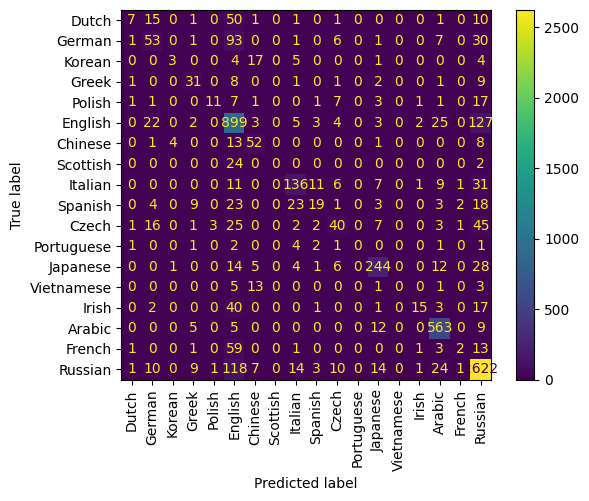

In [18]:
cm = confusion_matrix(y_true,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_categories)
disp.plot(xticks_rotation=90)
plt.show()

In [19]:
correct = cm.diagonal().sum()
total = cm.sum()
acc = correct/total * 100
print(f"Accuracy : {acc}%")

Accuracy : 77.98439315955504%


##Problem 2 - Custom RNN

In [22]:
class CustomRNN(nn.Module):
  def __init__(self, input_size, hidden_size):
    super(CustomRNN,self).__init__()
    self.hidden_size = hidden_size
    self.Wx = nn.Linear(input_size, hidden_size)
    self.Wh = nn.Linear(hidden_size, hidden_size)

  def step(self, x_t, hidden_size):
    hidden = torch.tanh(self.Wx(x_t) + self.Wh(hidden_size))
    return hidden

  def forward(self, x):
    seq_len, batch_size, input_size = x.size()
    hidden = torch.zeros(batch_size, self.hidden_size)
    for t in range(seq_len):
      x_t = x[t]
      hidden = self.step(x_t,hidden)

    return hidden

In [23]:
class Classifier(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(Classifier, self).__init__()
    self.rnn = CustomRNN(input_size, hidden_size)
    self.fc = nn.Linear(hidden_size, num_classes)
    self.softmax = nn.LogSoftmax(dim=1)

  def forward(self,x):
    hidden = self.rnn(x)
    out = self.fc(hidden)
    out = self.softmax(out)
    return out

In [24]:
model = Classifier(n_letters, 128, n_category)
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [25]:
epochs = 10

for epoch in range(epochs):
  total_loss = 0
  for batch in train_batches:
    optimizer.zero_grad()
    batch_loss = 0

    for name,label in batch:
      x = lineToTensor(name)
      target = torch.tensor([label])
      output = model(x)
      loss = criterion(output,target)
      batch_loss += loss

    batch_loss = batch_loss/len(batch)
    batch_loss.backward()
    optimizer.step()
    total_loss += batch_loss.item()

  print(f"Epoch:{epoch+1}, Loss:{total_loss:.4f}")

Epoch:1, Loss:348.9316
Epoch:2, Loss:250.6878
Epoch:3, Loss:217.1465
Epoch:4, Loss:198.9125
Epoch:5, Loss:185.4504
Epoch:6, Loss:174.9371
Epoch:7, Loss:166.0427
Epoch:8, Loss:158.2556
Epoch:9, Loss:151.3164
Epoch:10, Loss:145.0822


In [26]:
y_true = []
y_pred = []

with torch.no_grad():
  for name,label in test_data:
    x = lineToTensor(name)
    output = model(x)
    pred = torch.argmax(output).item()
    y_pred.append(pred)
    y_true.append(label)

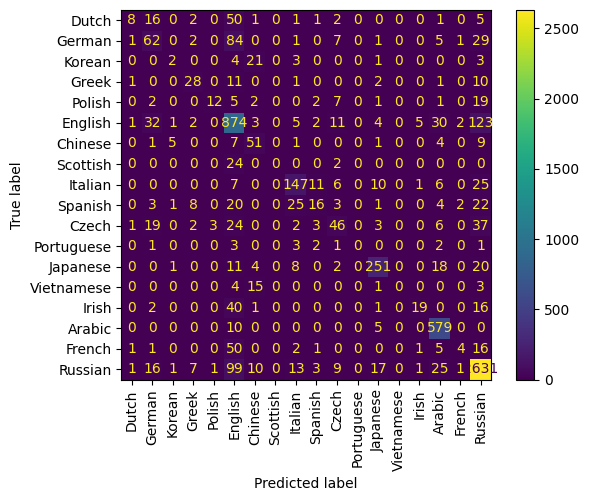

In [27]:
cm = confusion_matrix(y_true,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_categories)
disp.plot(xticks_rotation=90)
plt.show()

In [28]:
correct = cm.diagonal().sum()
total = cm.sum()
acc = correct/total * 100
print(f"Accuracy : {acc}%")

Accuracy : 78.53229287730366%
